## Dataset loading 

Dataset is the only input required by this packages, this notebook shows how to create Dataset that matches data flow of the packages. 

- However create numerical problem
- Load the Plasticity law dataset

In [2]:
# import packages
import numpy as np
import torch
import matplotlib.pyplot as plt


### 1. Create numerical problem

Numerical function is one of the fast way to generate data to test a machine learning model. With this package, we provide this example to show how to set a numerical problem and how to prescribe noise accordingly.
 

In [3]:
def Xsin(x:torch.Tensor, train=False, noise_type: str= "homo") -> torch.Tensor:
    """ Xsin function with noise

    Parameters
    ----------
    x : torch.Tensor
        input tensor of the Xsin function
    train : bool, optional
        generating training or testing data, by default False
    noise_type : str, optional
        define the noise, by default "homo"

    Returns
    -------
    Responses
        responses of the input data points
    """
    if not train:
        return x * torch.sin(x)
    else:
        if noise_type == "heter":
            return x * torch.sin(x) + torch.abs(x) * torch.randn_like(x) * 0.3 + torch.randn_like(x) * 0.3
        elif noise_type == "homo":
            x * torch.sin(x) + torch.randn_like(x) * 0.5

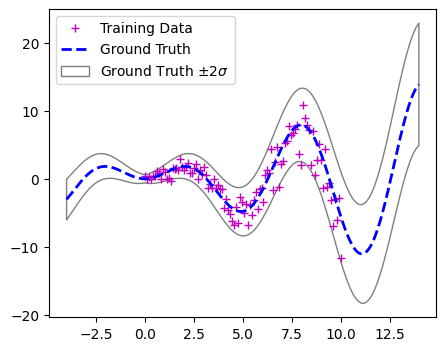

In [ ]:
# generate data based on the defined function
samples = torch.linspace(0, 10, 100).reshape(-1, 1)
responses = Xsin(samples, train=True, noise_type="heter")
plot_samples = torch.linspace(-4, 14, 1400).reshape(-1, 1)
ground_truth = Xsin(plot_samples, train=False)


# plot the Xsin function
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(samples, responses, "m+", label="Training Data")
ax.plot(plot_samples, ground_truth,  "b--",
               linewidth=2, label="Ground Truth")
ax.fill_between(
        plot_samples.squeeze(),
        (ground_truth - 2*(torch.abs(plot_samples)*0.3 + 0.3)).squeeze(),
        (ground_truth + 2*(torch.abs(plot_samples)*0.3 + 0.3)).squeeze(),
        color="gray",
        edgecolor="black",
        facecolor="None",
        alpha=0.5,
        label=r"Ground Truth $\pm 2\sigma$",
    )
plt.legend()
plt.show()


To this end, one can develop their own numerical case as following the same format. 

### 2. Plasticity Law Discovery Dataset


The fundamental mechanical law of materials is called a **constitutive law**. It relates average material **deformations** to average material **stresses** at any point in a structure. Constitutive laws can model different physics behaviors, such as **elasticity**, **hyperelasticity**, **plasticity**, and **damage**. In this dataset, we focus on generating datasets for **plastically deforming composite materials**, following prior work about Cooperative Data-Driven Modeling ([CDDM](https://www.sciencedirect.com/science/article/abs/pii/S004578252300556X)) . Without loss of generality, the constitutive law of such **path-dependent materials** can be written as:

$$
\mathbf{y} = f(\mathbf{x}, \dot{\mathbf{x}}, \tau, \dot{\tau}, \mathbf{h})
$$

where:

- $\mathbf{y}$ — stress  
- $\mathbf{x}$ — strain  
- $\tau$ — temperature  
- $\mathbf{h}$ — internal state variables  

These constitutive responses are predicted by **micro-scale FEM simulations** of material domains called **stochastic volume elements (SVEs)**. 

<div align="center">
    <img src="../docs/logo/sve_contour.png" alt="sve_contour" width="800"/>
</div>

Each SVE serves as a basic material simulation unit. Many factors introduce uncertainty in the data generation process. Here, we analyze two major sources:

1. **SVE size**  
2. **Particle distribution variability**  

Randomizing the particle distribution leads the resulting stress response for the same input deformation to exhibit **stochasticity (aleatoric uncertainty)**, which can observed with the `plot_test_function` of the `PlasticityLaw` class.

Two datasets are therefore generated from simulations according to the Table.

| Name       | $v_f$ | $r$    | $r_{\mathrm{std}}$ | Hardening Law                                  | $E_{\mathrm{fiber}}$ | Size   | $E_{\mathrm{matrix}}$ | $\nu_{\mathrm{matrix}}$ | $\nu_{\mathrm{fiber}}$ |
|-----------|-------|--------|--------------------|------------------------------------------------|----------------------|--------|------------------------|--------------------------|------------------------|
| Material 1 | 0.30  | 0.003  | 0.0                | $\sigma_{y} = 0.5 + 0.5(\bar{\epsilon})^{0.4}$ | 1                    | 0.048  | 100                    | 0.30                     | 0.19                   |
| Material 2 | 0.30  | 0.003  | 0.0                | $\sigma_{y} = 0.5 + 0.5(\bar{\epsilon})^{0.4}$ | 1                    | 0.030  | 100                    | 0.30                     | 0.19                   |






In [5]:
# import the corresponding function for Bayes datasets
from VeBNN.problems import PlasticityLaw

In [11]:
# load the dataset
plasticity_dataset = PlasticityLaw(dataset_path="plasticity_discovery/material_2_training_dataset.pickle",
                                  ground_truth=True,
                                  ground_truth_data_path="plasticity_discovery/material_2_testing_dataset.pickle")

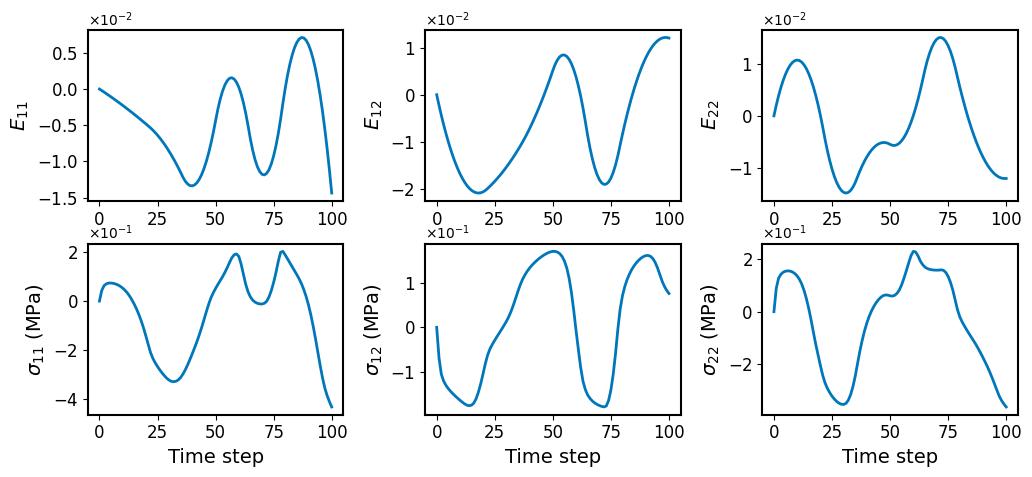

In [12]:
# visualization of the training data for specific index
plasticity_dataset.plot_training_data(index=0)

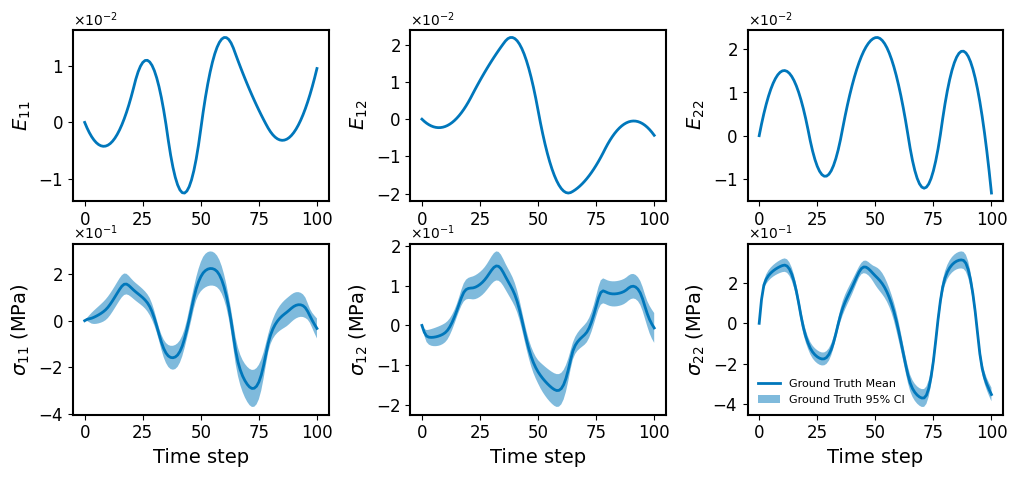

In [13]:
# visualize the test data with ground truth
plasticity_dataset.plot_test_data(index=2)

**Have fun with it !**